# IT Incident Management and SLA Performance Analysis

**Jake Sheeler**  
**October 7, 2026**

ServiceNow incident lifecycle analysis using Python, SQL Server, and Power BI.

## Dataset Citation

Amaral, C., Fantinato, M., & Peres, S. (2018). *Incident management process enriched event log* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C57S4H


## 1. Setting up the tools



In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

def Number_Format(Value):
    return f"{Value:,.2f}"

pd.set_option("display.float_format", Number_Format)

ROOT = Path.cwd()

CSV_Options = [
    ROOT / "incident_event_log.csv",
    ROOT / "data" / "incident_event_log.csv",
    ROOT / "incident+management+process+enriched+event+log" / "incident_event_log.csv"
]

DATA_FILE = next(
    (CSV_Path for CSV_Path in CSV_Options if CSV_Path.exists()),
    None
)

OUTPUT_FOLDER = ROOT / "outputs"
OUTPUT_FOLDER.mkdir(exist_ok=True)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Could not find incident_event_log.csv. Place the CSV beside the notebook "
        "or inside a data folder."
    )

print(DATA_FILE)


C:\Users\sheel\IT Incident Management Analysis\incident+management+process+enriched+event+log\incident_event_log.csv


## 2. Loading the Data



In [4]:
Encoding_Options = ["utf8", "utf8-sig", "latin1"]
Incident_Source = None
Load_Errors = {}

for encoding in Encoding_Options:
    try:
        Incident_Source = pd.read_csv(
            DATA_FILE,
            dtype="string",
            low_memory=False,
            encoding=encoding,
            on_bad_lines="error"
        )
        Selected_Encoding = encoding
        break
    except (UnicodeDecodeError, pd.errors.ParserError) as error:
        Load_Errors[encoding] = str(error)

if Incident_Source is None:
    raise ValueError(f"The CSV could not be loaded. Errors: {Load_Errors}")

Required_Columns = {
    "number", "incident_state", "reassignment_count", "reopen_count",
    "sys_mod_count", "made_sla", "opened_at", "sys_updated_at",
    "category", "subcategory", "priority", "assignment_group",
    "assigned_to", "resolved_at", "closed_at"
}

Standard_Columns = (
    Incident_Source.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

Missing_Columns = Required_Columns.difference(Standard_Columns)
if Missing_Columns:
    raise ValueError(f"Required columns are missing: {sorted(Missing_Columns)}")

Incident_Raw = Incident_Source.copy(deep=True)
Incident_Events = Incident_Source.copy()
Incident_Events.columns = Standard_Columns

Missing_Values = ["?", "", "nan", "none", "null", "nat", "unknown"]
Text_Columns = Incident_Events.select_dtypes(include="string").columns

for col in Text_Columns:
    Incident_Events.loc[:, col] = Incident_Events[col].str.strip()

Incident_Events.loc[:, Text_Columns] = Incident_Events[Text_Columns].replace(
    Missing_Values,
    pd.NA
)

print(f"Encoding: {Selected_Encoding}")
print(f"Rows: {len(Incident_Events):,}")
print(f"Columns: {Incident_Events.shape[1]:,}")
display(Incident_Events.head())


Encoding: utf8
Rows: 141,712
Columns: 36


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,true,0,0,0,true,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,<NA>,2 - Medium,2 - Medium,3 - Moderate,Group 56,<NA>,true,false,Do Not Notify,<NA>,<NA>,<NA>,<NA>,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,true,0,0,2,true,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,<NA>,2 - Medium,2 - Medium,3 - Moderate,Group 56,<NA>,true,false,Do Not Notify,<NA>,<NA>,<NA>,<NA>,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,true,0,0,3,true,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,<NA>,2 - Medium,2 - Medium,3 - Moderate,Group 56,<NA>,true,false,Do Not Notify,<NA>,<NA>,<NA>,<NA>,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,false,0,0,4,true,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,<NA>,2 - Medium,2 - Medium,3 - Moderate,Group 56,<NA>,true,false,Do Not Notify,<NA>,<NA>,<NA>,<NA>,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,true,0,0,0,true,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,<NA>,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,true,false,Do Not Notify,<NA>,<NA>,<NA>,<NA>,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


## 3. Checking data quality



In [5]:
def Quality_Profile(df):
    rows = []
    for col in df.columns:
        Example_Values = df[col].dropna().astype(str).unique()[:3]
        rows.append({"column_name": col, "data_type": str(df[col].dtype),
                     "row_count": len(df), "non_null_count": int(df[col].notna().sum()),
                     "null_count": int(df[col].isna().sum()),
                     "null_percent": round(df[col].isna().mean() * 100, 2),
                     "distinct_count": int(df[col].nunique(dropna=True)),
                     "examples": " | ".join(Example_Values)})
    return pd.DataFrame(rows).sort_values(["null_percent", "distinct_count"], ascending=[False, True])

Data_Quality = Quality_Profile(Incident_Events)
display(Data_Quality)
Data_Quality.to_csv(OUTPUT_FOLDER / "raw_data_quality_profile.csv", index=False)


,column_name,data_type,row_count,non_null_count,null_count,null_percent,distinct_count,examples
31,caused_by,string,141712,23,141689,99.98,3,CHG0000132 | CHG0000097 | CHG0001327
30,vendor,string,141712,244,141468,99.83,4,code 8s | Vendor 3 | Vendor 2
19,cmdb_ci,string,141712,445,141267,99.69,50,cmdb_ci 31 | cmdb_ci 23 | cmdb_ci 22
29,rfc,string,141712,991,140721,99.30,181,CHG0000404 | CHG0000647 | CHG0000127
28,problem_id,string,141712,2295,139417,98.38,252,Problem ID 2 | Problem ID 4 | Problem ID 44
10,sys_created_by,string,141712,88636,53076,37.45,185,Created by 6 | Created by 171 | Created by 81
11,sys_created_at,string,141712,88636,53076,37.45,11552,29/2/2016 01:23 | 29/2/2016 04:57 | 29/2/2016 ...
18,u_symptom,string,141712,108748,32964,23.26,525,Symptom 72 | Symptom 471 | Symptom 450
24,assigned_to,string,141712,114216,27496,19.40,234,Resolver 89 | Resolver 31 | Resolver 6
23,assignment_group,string,141712,127499,14213,10.03,78,Group 56 | Group 70 | Group 24


## 4. Fixing data types



In [6]:
Date_Columns = ["opened_at", "sys_created_at", "sys_updated_at", "resolved_at", "closed_at"]
Count_Columns = [
    "reassignment_count",
    "reopen_count",
    "sys_mod_count"
]

Level_Columns = [
    "impact",
    "urgency",
    "priority"
]

Boolean_Columns = [
    "active",
    "made_sla",
    "knowledge",
    "u_priority_confirmation"
]

Raw_Dates = Incident_Events.loc[:, Date_Columns].copy()

for Column_Name in Date_Columns:
    Incident_Events[Column_Name] = pd.to_datetime(
        Incident_Events[Column_Name],
        errors="coerce",
        dayfirst=True
    )

for Column_Name in Count_Columns:
    Incident_Events[Column_Name] = pd.to_numeric(
        Incident_Events[Column_Name],
        errors="coerce"
    ).astype("Int64")

for Column_Name in Level_Columns:
    Incident_Events[Column_Name] = (
        Incident_Events[Column_Name]
        .str.extract(r"^(\d+)", expand=False)
        .astype("Int64")
    )

Boolean_Map = {
    "true": True,
    "false": False,
    "1": True,
    "0": False,
    "yes": True,
    "no": False
}

for Column_Name in Boolean_Columns:
    Incident_Events[Column_Name] = (
        Incident_Events[Column_Name]
        .astype("string")
        .str.lower()
        .map(Boolean_Map)
        .astype("boolean")
    )

Date_Validation = pd.DataFrame({
    "column_name": Date_Columns,
    "source_non_null": [int(Raw_Dates[Column_Name].notna().sum()) for Column_Name in Date_Columns],
    "parse_failures": [int((Raw_Dates[Column_Name].notna() & Incident_Events[Column_Name].isna()).sum()) for Column_Name in Date_Columns]
})
display(Date_Validation)


,column_name,source_non_null,parse_failures
0,opened_at,141712,0
1,sys_created_at,88636,0
2,sys_updated_at,141712,0
3,resolved_at,138571,0
4,closed_at,141712,0


## 5. Ordering event data



In [7]:
Incident_Events["source_row_number"] = np.arange(1, len(Incident_Events) + 1)
Incident_Events["is_exact_repeated_row"] = Incident_Events.drop(columns="source_row_number").duplicated()
Incident_Events["is_repeated_event_key"] = Incident_Events.duplicated(subset=["number", "sys_updated_at", "sys_mod_count"], keep=False)
Incident_Events = Incident_Events.sort_values(["number", "sys_updated_at", "sys_mod_count", "source_row_number"], na_position="last").reset_index(drop=True)
Incident_Events["event_sequence"] = Incident_Events.groupby("number").cumcount() + 1
Incident_Events["event_count"] = Incident_Events.groupby("number")["number"].transform("size")
Incident_Events["is_latest_event"] = Incident_Events["event_sequence"].eq(Incident_Events["event_count"])
Incident_Events["next_updated_at"] = Incident_Events.groupby("number")["sys_updated_at"].shift(-1)
Incident_Events["event_duration_hours"] = Incident_Events["next_updated_at"].sub(Incident_Events["sys_updated_at"]).dt.total_seconds().div(3600)

for field in ["incident_state", "assignment_group", "assigned_to"]:
    Incident_Events[f"previous_{field}"] = Incident_Events.groupby("number")[field].shift(1)
    Incident_Events[f"{field}_changed"] = Incident_Events[f"previous_{field}"].notna() & Incident_Events[field].ne(Incident_Events[f"previous_{field}"])

print(f"Exact repeated rows after first: {Incident_Events['is_exact_repeated_row'].sum():,}")
print(f"Rows in repeated event keys: {Incident_Events['is_repeated_event_key'].sum():,}")
print(f"Negative event durations: {Incident_Events['event_duration_hours'].lt(0).sum():,}")


Exact repeated rows after first: 0
Rows in repeated event keys: 0
Negative event durations: 0


## 6. Summarizing incidents



In [8]:
Latest_Incident_Event = Incident_Events.loc[Incident_Events["is_latest_event"]].copy().set_index("number")
Incident_History = Incident_Events.groupby("number").agg(
    recorded_event_count=("number", "size"),
    first_recorded_update=("sys_updated_at", "min"),
    last_recorded_update=("sys_updated_at", "max"),
    observed_state_count=("incident_state", "nunique"),
    observed_assignment_group_count=("assignment_group", "nunique"),
    observed_assignee_count=("assigned_to", "nunique"),
    state_change_count=("incident_state_changed", "sum"),
    observed_group_change_count=("assignment_group_changed", "sum"),
    observed_assignee_change_count=("assigned_to_changed", "sum"),
    measured_event_hours=("event_duration_hours", "sum"))
Incident_Summary = Latest_Incident_Event.join(Incident_History, how="left").reset_index()
print(f"Incident rows: {len(Incident_Summary):,}")
print(f"Unique incidents: {Incident_Summary['number'].nunique():,}")


Incident rows: 24,918
Unique incidents: 24,918


## 7. Creating key metrics



In [9]:
Incident_Summary["resolution_hours"] = Incident_Summary["resolved_at"].sub(Incident_Summary["opened_at"]).dt.total_seconds().div(3600)
Incident_Summary["closure_hours"] = Incident_Summary["closed_at"].sub(Incident_Summary["opened_at"]).dt.total_seconds().div(3600)
Incident_Summary["post_resolution_close_hours"] = Incident_Summary["closed_at"].sub(Incident_Summary["resolved_at"]).dt.total_seconds().div(3600)
Incident_Summary["sla_met_flag"] = Incident_Summary["made_sla"].astype("boolean")
Incident_Summary["sla_breach_flag"] = Incident_Summary["made_sla"].eq(False).astype("boolean")
Incident_Summary["reassigned_flag"] = Incident_Summary["reassignment_count"].gt(0)
Incident_Summary["reopened_flag"] = Incident_Summary["reopen_count"].gt(0)
Incident_Summary["high_handoff_flag"] = Incident_Summary["reassignment_count"].ge(3)
Incident_Summary["reassignment_group"] = pd.cut(Incident_Summary["reassignment_count"], [-np.inf, 0, 1, 2, np.inf], labels=["0", "1", "2", "3 or more"])
Incident_Summary["resolution_group"] = pd.cut(Incident_Summary["resolution_hours"], [-np.inf, 4, 8, 24, 72, np.inf], labels=["0 to 4 hours", "4 to 8 hours", "8 to 24 hours", "1 to 3 days", "More than 3 days"], right=False)
Incident_Summary["opened_date"] = Incident_Summary["opened_at"].dt.date
Incident_Summary["opened_month"] = Incident_Summary["opened_at"].dt.to_period("M").astype("string")
Incident_Summary["opened_year"] = Incident_Summary["opened_at"].dt.year.astype("Int64")
Incident_Summary["opened_weekday"] = Incident_Summary["opened_at"].dt.day_name()
Incident_Summary["opened_hour"] = Incident_Summary["opened_at"].dt.hour.astype("Int64")
Incident_Summary["invalid_resolution_sequence"] = Incident_Summary["opened_at"].notna() & Incident_Summary["resolved_at"].notna() & Incident_Summary["resolved_at"].lt(Incident_Summary["opened_at"])
Incident_Summary["invalid_closure_sequence"] = Incident_Summary["resolved_at"].notna() & Incident_Summary["closed_at"].notna() & Incident_Summary["closed_at"].lt(Incident_Summary["resolved_at"])
Incident_Summary["included_in_resolution_analysis"] = Incident_Summary["number"].notna() & Incident_Summary["opened_at"].notna() & Incident_Summary["resolved_at"].notna() & Incident_Summary["resolution_hours"].ge(0)
Incident_Analysis = Incident_Summary.loc[Incident_Summary["included_in_resolution_analysis"]].copy()
display(Incident_Summary[["number", "resolution_hours", "made_sla", "reassignment_group", "resolution_group"]].head())


,number,resolution_hours,made_sla,reassignment_group,resolution_group
0,INC0000045,10.22,True,0,8 to 24 hours
1,INC0000047,29.20,True,1,1 to 3 days
2,INC0000057,20.75,True,0,8 to 24 hours
3,INC0000060,53.47,True,0,1 to 3 days
4,INC0000062,8.88,False,1,8 to 24 hours


## 8. Validating cleaned data



In [10]:
Validation_Summary = pd.DataFrame({
    "check": ["missing number", "missing opened time", "missing resolved time", "missing closed time", "invalid resolution sequence", "invalid closure sequence"],
    "count": [Incident_Summary["number"].isna().sum(), Incident_Summary["opened_at"].isna().sum(), Incident_Summary["resolved_at"].isna().sum(), Incident_Summary["closed_at"].isna().sum(), Incident_Summary["invalid_resolution_sequence"].sum(), Incident_Summary["invalid_closure_sequence"].sum()]})
Known_SLA = int(Incident_Summary["made_sla"].notna().sum())
Met_SLA = int(Incident_Summary["made_sla"].eq(True).sum())
def Percent_Value(Numerator, Denominator):
    if Denominator == 0:
        return np.nan

    return Numerator / Denominator * 100
KPI_Summary = pd.DataFrame({"metric": ["Event rows", "Unique incidents", "Known SLA status", "SLA compliance percent", "Average resolution hours", "Median resolution hours", "Reassigned percent", "Reopened percent", "Assignment groups", "Categories"], "value": [len(Incident_Events), Incident_Summary["number"].nunique(), Known_SLA, Percent_Value(Met_SLA, Known_SLA), Incident_Analysis["resolution_hours"].mean(), Incident_Analysis["resolution_hours"].median(), Incident_Summary["reassigned_flag"].mean() * 100, Incident_Summary["reopened_flag"].mean() * 100, Incident_Events["assignment_group"].nunique(), Incident_Summary["category"].nunique()]})
display(Validation_Summary)
display(KPI_Summary)


,check,count
0,missing number,0
1,missing opened time,0
2,missing resolved time,1556
3,missing closed time,0
4,invalid resolution sequence,0
5,invalid closure sequence,0


,metric,value
0,Event rows,"141,712.00"
1,Unique incidents,"24,918.00"
2,Known SLA status,"24,918.00"
3,SLA compliance percent,63.42
4,Average resolution hours,178.17
5,Median resolution hours,22.10
6,Reassigned percent,45.63
7,Reopened percent,1.10
8,Assignment groups,78.00
9,Categories,52.00


## 9. Analyzing performance



In [11]:
def Operational_Summary(df, Group_Column):
    Summary_Data = df.groupby(Group_Column, dropna=False, observed=False).agg(
        incident_count=("number", "nunique"), sla_known_count=("made_sla", "count"),
        sla_met_count=("sla_met_flag", "sum"), average_resolution_hours=("resolution_hours", "mean"),
        median_resolution_hours=("resolution_hours", "median"), average_reassignments=("reassignment_count", "mean"),
        reopened_count=("reopened_flag", "sum")).reset_index()
    Summary_Data["sla_compliance_percent"] = np.where(Summary_Data["sla_known_count"].gt(0), Summary_Data["sla_met_count"].div(Summary_Data["sla_known_count"]).mul(100), np.nan)
    Summary_Data["reopened_percent"] = np.where(Summary_Data["incident_count"].gt(0), Summary_Data["reopened_count"].div(Summary_Data["incident_count"]).mul(100), np.nan)
    return Summary_Data.sort_values("incident_count", ascending=False)

Priority_Performance = Operational_Summary(Incident_Analysis, "priority")
Category_Performance = Operational_Summary(Incident_Analysis, "category")
Assignment_Group_Performance = Operational_Summary(Incident_Analysis, "assignment_group")
Reassignment_Impact = Operational_Summary(Incident_Analysis, "reassignment_group")
display(Priority_Performance)
display(Category_Performance.head(15))
display(Reassignment_Impact.sort_values("reassignment_group"))


,priority,incident_count,sla_known_count,sla_met_count,average_resolution_hours,median_resolution_hours,average_reassignments,reopened_count,sla_compliance_percent,reopened_percent
2,3,22010,22010,13874,174.35,21.55,0.99,267,63.03,1.21
3,4,674,674,551,283.19,5.02,0.93,2,81.75,0.30
1,2,408,408,2,152.46,38.23,1.46,5,0.49,1.23
0,1,270,270,5,266.08,80.24,1.16,0,1.85,0.00


,category,incident_count,sla_known_count,sla_met_count,average_resolution_hours,median_resolution_hours,average_reassignments,reopened_count,sla_compliance_percent,reopened_percent
27,Category 42,3138,3138,2495,98.55,0.63,0.75,32,79.51,1.02
14,Category 26,3045,3045,2052,83.29,5.58,1.05,39,67.39,1.28
38,Category 53,2587,2587,1590,128.12,27.88,1.02,38,61.46,1.47
31,Category 46,2356,2356,1120,316.02,65.71,0.91,15,47.54,0.64
19,Category 32,1268,1268,933,64.93,1.14,0.88,19,73.58,1.50
51,Category 9,1121,1121,655,156.23,45.77,0.64,17,58.43,1.52
23,Category 37,1098,1098,714,129.43,22.55,0.94,12,65.03,1.09
11,Category 23,1055,1055,554,151.58,46.30,1.76,12,52.51,1.14
42,Category 57,961,961,573,161.84,42.58,1.41,17,59.63,1.77
8,Category 20,931,931,697,58.50,1.90,0.97,12,74.87,1.29


,reassignment_group,incident_count,sla_known_count,sla_met_count,average_resolution_hours,median_resolution_hours,average_reassignments,reopened_count,sla_compliance_percent,reopened_percent
0,0,12003,12003,9251,94.98,0.68,0.00,61,77.07,0.51
1,1,6228,6228,3559,173.32,42.05,1.00,63,57.15,1.01
2,2,2283,2283,910,315.63,102.97,2.00,45,39.86,1.97
3,3 or more,2848,2848,712,429.20,191.83,4.43,105,25.00,3.69


## 10. Measuring wait times



In [12]:
Assignment_Group_Time = (Incident_Events.loc[Incident_Events["event_duration_hours"].ge(0) & Incident_Events["assignment_group"].notna()]
              .groupby("assignment_group").agg(incidents_touched=("number", "nunique"),
              recorded_intervals=("event_duration_hours", "count"), total_observed_hours=("event_duration_hours", "sum"),
              average_interval_hours=("event_duration_hours", "mean"), median_interval_hours=("event_duration_hours", "median"))
              .reset_index().sort_values("total_observed_hours", ascending=False))
Opened_Incidents = Incident_Summary.loc[
    Incident_Summary["opened_at"].notna(),
    ["number", "opened_at"]
].copy()

Opened_Incidents.loc[:, "month"] = (
    Opened_Incidents["opened_at"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

Created_Monthly = (
    Opened_Incidents.groupby("month")["number"]
    .nunique()
    .rename("created_incidents")
)

Resolved_Incidents = Incident_Summary.loc[
    Incident_Summary["resolved_at"].notna(),
    ["number", "resolved_at"]
].copy()

Resolved_Incidents.loc[:, "month"] = (
    Resolved_Incidents["resolved_at"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

Resolved_Monthly = (
    Resolved_Incidents.groupby("month")["number"]
    .nunique()
    .rename("resolved_incidents")
)

Monthly_Incident_Flow = pd.concat(
    [Created_Monthly, Resolved_Monthly],
    axis=1
)

Monthly_Incident_Flow = Monthly_Incident_Flow.fillna(0).astype(int).reset_index()

Monthly_Incident_Flow.loc[:, "net_flow"] = (
    Monthly_Incident_Flow["created_incidents"]
    .sub(Monthly_Incident_Flow["resolved_incidents"])
)
display(Assignment_Group_Time.head(20))
display(Monthly_Incident_Flow)


,assignment_group,incidents_touched,recorded_intervals,total_observed_hours,average_interval_hours,median_interval_hours
63,Group 70,15254,34030,"1,497,979.07",44.02,2.57
77,Group 9,454,1550,"686,990.12",443.22,120.11
16,Group 25,1678,6436,"463,050.73",71.95,18.19
11,Group 20,2652,5776,"324,167.22",56.12,1.62
0,Group 10,525,1667,"257,819.18",154.66,90.95
58,Group 66,646,1743,"248,418.08",142.52,22.25
15,Group 24,1403,5692,"246,994.12",43.39,1.65
31,Group 39,1509,3529,"240,823.58",68.24,15.25
23,Group 31,308,924,"181,511.38",196.44,28.22
65,Group 72,577,1853,"178,099.78",96.11,14.40


,month,created_incidents,resolved_incidents,net_flow
0,2016-02-01,207,36,171
1,2016-03-01,8995,6878,2117
2,2016-04-01,7934,7794,140
3,2016-05-01,7508,7150,358
4,2016-06-01,5,875,-870
5,2016-07-01,14,140,-126
6,2016-08-01,15,75,-60
7,2016-09-01,12,50,-38
8,2016-10-01,16,79,-63
9,2016-11-01,26,62,-36


## 11. Visualizing key patterns



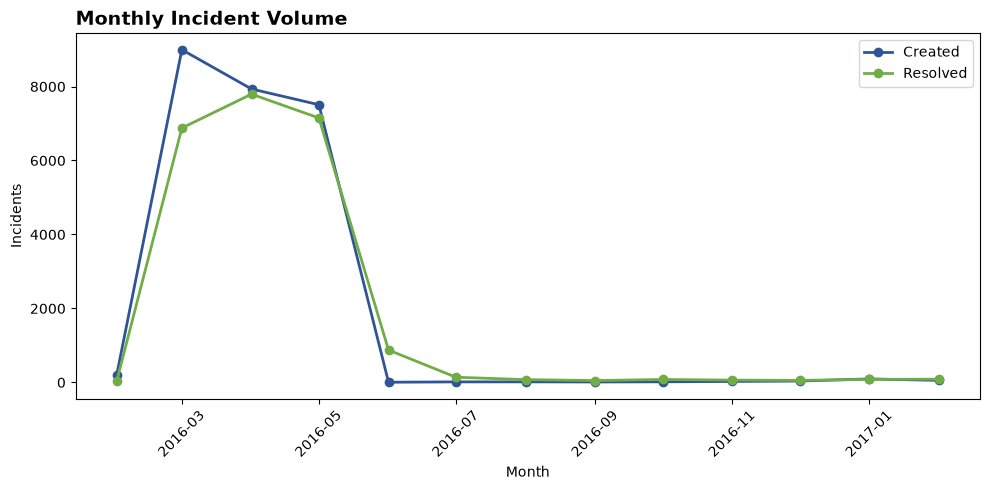

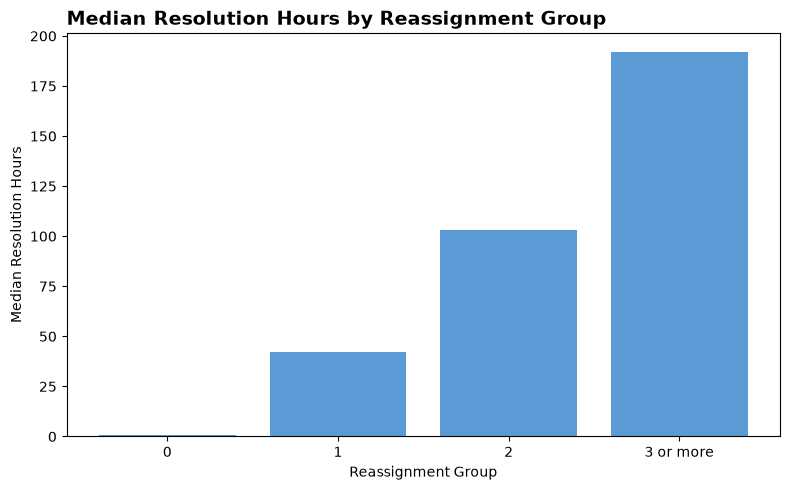

In [13]:
plt.figure(figsize=(10, 5), facecolor="white")
plt.plot(Monthly_Incident_Flow["month"], Monthly_Incident_Flow["created_incidents"], marker="o", color="#2F5597", linewidth=2, label="Created")
plt.plot(Monthly_Incident_Flow["month"], Monthly_Incident_Flow["resolved_incidents"], marker="o", color="#70AD47", linewidth=2, label="Resolved")
plt.title("Monthly Incident Volume", loc="left", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Incidents")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "monthly_incident_volume.png", dpi=150, bbox_inches="tight")
plt.show()

Reassignment_Plot = Reassignment_Impact.sort_values("reassignment_group")
plt.figure(figsize=(8, 5), facecolor="white")
plt.bar(Reassignment_Plot["reassignment_group"].astype(str), Reassignment_Plot["median_resolution_hours"], color="#5B9BD5")
plt.title("Median Resolution Hours by Reassignment Group", loc="left", fontsize=14, fontweight="bold")
plt.xlabel("Reassignment Group")
plt.ylabel("Median Resolution Hours")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "reassignment_impact.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Exporting cleaned data



In [15]:
Incident_Events.to_csv(OUTPUT_FOLDER / "incident_events_clean.csv", index=False, date_format="%Y-%m-%d %H:%M:%S")
Incident_Summary.to_csv(OUTPUT_FOLDER / "incident_summary_clean.csv", index=False, date_format="%Y-%m-%d %H:%M:%S")
KPI_Summary.to_csv(OUTPUT_FOLDER / "kpi_summary.csv", index=False)
Validation_Summary.to_csv(OUTPUT_FOLDER / "validation_summary.csv", index=False)
Priority_Performance.to_csv(OUTPUT_FOLDER / "priority_performance.csv", index=False)
Category_Performance.to_csv(OUTPUT_FOLDER / "category_performance.csv", index=False)
Assignment_Group_Performance.to_csv(OUTPUT_FOLDER / "assignment_group_performance.csv", index=False)
Reassignment_Impact.to_csv(OUTPUT_FOLDER / "reassignment_impact.csv", index=False)
Assignment_Group_Time.to_csv(OUTPUT_FOLDER / "assignment_group_time_summary.csv", index=False)
Monthly_Incident_Flow.to_csv(OUTPUT_FOLDER / "monthly_incident_trend.csv", index=False, date_format="%Y-%m-%d")
Quality_Profile(Incident_Summary).to_csv(OUTPUT_FOLDER / "clean_incident_quality_profile.csv", index=False)
print("Exported files:")
for file in sorted(OUTPUT_FOLDER.iterdir()): print(file.name)


Exported files:
.ipynb_checkpoints
assignment_group_performance.csv
assignment_group_time_summary.csv
category_performance.csv
clean_incident_quality_profile.csv
incident_events_clean.csv
incident_summary_clean.csv
kpi_summary.csv
monthly_incident_trend.csv
monthly_incident_volume.png
priority_performance.csv
raw_data_quality_profile.csv
reassignment_impact.csv
reassignment_impact.png
validation_summary.csv
